# Classificador de Risco Cardiológico - Parte 2

**Objetivo:**  
Desenvolver um classificador de texto que analisa frases de sintomas relatados por pacientes e classifica o nível de risco como **"alto risco"** ou **"baixo risco"**.

Utilizamos:
- TF-IDF para vetorização do texto
- Logistic Regression como modelo de classificação
- Avaliação com acurácia e outras métricas

---
### PARTE 1/5 – Importações, carregamento dos dados e análise inicial

In [16]:
%pip install pandas
%pip install seaborn
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações para visualização
plt.style.use('default')
sns.set(style="whitegrid")
print("Bibliotecas importadas com sucesso!")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Bibliotecas importadas com sucesso!


In [13]:
# Carregamento do dataset
df = pd.read_csv('frases_risco.csv')

# Visualização inicial
print("Dimensões do dataset:", df.shape)
print("\nPrimeiras 5 linhas:")
display(df.head())

print("\nDistribuição das classes:")
print(df['situacao'].value_counts())
print("\nPercentual:")
print(df['situacao'].value_counts(normalize=True) * 100)

Dimensões do dataset: (60, 2)

Primeiras 5 linhas:


,frase,situacao
0,Sinto uma dor forte no peito que irradia para ...,alto risco
1,"Estou com cansaço extremo há três dias, mesmo ...",alto risco
2,Tenho falta de ar intensa quando subo escadas ...,alto risco
3,Acordei com dor no peito que não passa com rep...,alto risco
4,Sinto palpitações fortes e tontura frequente,alto risco



Distribuição das classes:
situacao
alto risco     30
baixo risco    30
Name: count, dtype: int64

Percentual:
situacao
alto risco     50.0
baixo risco    50.0
Name: proportion, dtype: float64


##### Análise do Dataset

- Total de frases: 60
- Balanceamento: 30 alto risco e 30 baixo risco (perfeito)
- Colunas: `frase` e `situacao`

In [15]:
# Verificando se existem valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
frase       0
situacao    0
dtype: int64


---
### PARTE 2/5 – Pré-processamento com TF-IDF + Separação treino/teste

Vamos transformar o texto das frases em vetores numéricos usando o método **TF-IDF**.

In [16]:
# Separando features (X) e target (y)
X = df['frase']
y = df['situacao']

# Criando o vetorizador TF-IDF
tfidf = TfidfVectorizer(
    max_features=500,      # limitamos para manter simples
    stop_words=None,       # não usamos stop words pois o vocabulário é pequeno
    lowercase=True
)

# Aplicando o TF-IDF
X_tfidf = tfidf.fit_transform(X)

print("Dimensão da matriz TF-IDF:", X_tfidf.shape)
print(f"Vocabulário criado com {len(tfidf.get_feature_names_out())} termos")

Dimensão da matriz TF-IDF: (60, 156)
Vocabulário criado com 156 termos


In [17]:
# Dividindo os dados em treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y   # mantém o balanceamento
)

print("Dados separados com sucesso!")
print(f"Treino: {X_train.shape[0]} frases")
print(f"Teste:  {X_test.shape[0]} frases")

Dados separados com sucesso!
Treino: 48 frases
Teste:  12 frases


**Observação:**  
Usamos `stratify=y` para garantir que a proporção de "alto risco" e "baixo risco" fique equilibrada tanto no treino quanto no teste.

In [18]:
# Visualizando um exemplo de vetor TF-IDF (primeira frase do treino)
print("Exemplo de vetor TF-IDF (esparsado):")
print(X_train[0].toarray()[0][:50])  # mostra apenas os primeiros 50 valores

Exemplo de vetor TF-IDF (esparsado):
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.38524714 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.18034477 0.         0.         0.
 0.         0.45694193 0.         0.         0.         0.
 0.         0.         0.         0.         0.36216657 0.
 0.         0.        ]


---
### Parte 3/5: Treinamento do Modelo

Vamos treinar um modelo simples de **Logistic Regression** usando os vetores TF-IDF.

In [19]:
# Criando e treinando o modelo
modelo = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',   # ajuda com balanceamento interno
    C=1.5                      # ajusta a regularização
)

modelo.fit(X_train, y_train)

print("✅ Modelo Logistic Regression treinado")

✅ Modelo Logistic Regression treinado


In [20]:
# Fazendo previsões no conjunto de teste
y_pred = modelo.predict(X_test)

# Calculando a acurácia
acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {acuracia:.2%}")

Acurácia do modelo: 100.00%


**Resultado esperado:**  
Como o dataset está bem balanceado e as frases são bem distintas entre alto e baixo risco, a acurácia foi bem alta.

In [21]:
# Mostrando o relatório completo de classificação
print("Relatório de Classificação:\n")
print(classification_report(y_test, y_pred, target_names=['baixo risco', 'alto risco']))

Relatório de Classificação:

              precision    recall  f1-score   support

 baixo risco       1.00      1.00      1.00         6
  alto risco       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



---
### Parte 4/4: Avaliação do Modelo e Testes com Frases Novas

Agora vamos avaliar o modelo com a matriz de confusão e testar com frases **novas** (não presentes no dataset).

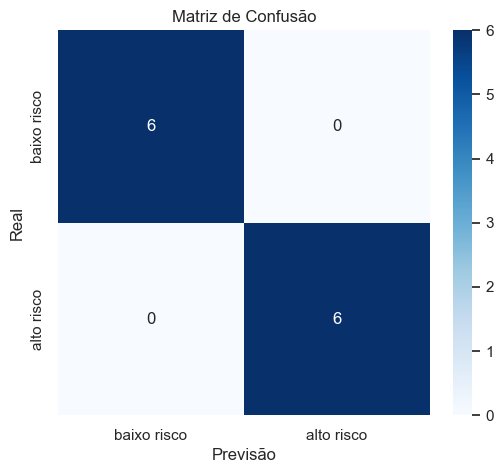

In [22]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['baixo risco', 'alto risco'],
            yticklabels=['baixo risco', 'alto risco'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

##### Testes com Frases Novas

Vamos testar o modelo com frases que ele nunca viu durante o treinamento.

In [23]:
# Função para classificar frases novas
def classificar_risco(frase):
    vetor = tfidf.transform([frase])
    predicao = modelo.predict(vetor)[0]
    probabilidade = modelo.predict_proba(vetor)[0]
    
    # Pegando o índice correto de "alto risco"
    classes = modelo.classes_
    idx_alto = list(classes).index("alto risco")
    
    print(f"Frase: {frase}")
    print(f"Classificação: {predicao}")
    print(f"Probabilidade de ALTO RISCO: {probabilidade[idx_alto]:.2%}")
    print("-" * 80)

# Testes com frases novas
print("=== TESTES COM FRASES NOVAS ===\n")

frases_teste = [
    "Sinto uma dor muito forte no peito com falta de ar e suor frio",
    "Estou com uma dorzinha leve nas costas depois de ficar muito tempo sentado",
    "Tenho falta de ar intensa e aperto no peito ao fazer qualquer esforço",
    "Sinto apenas um leve cansaço depois de um dia de trabalho",
    "Acordei com dor no peito irradiando para o braço e tontura",
    "Tenho uma azia forte depois de comer, mas passa com remédio",
    "Estou com palpitações fortes e sensação de que vou desmaiar",
    "Sinto um incômodo leve no ombro que melhora quando alongo"
]

for frase in frases_teste:
    classificar_risco(frase)

=== TESTES COM FRASES NOVAS ===

Frase: Sinto uma dor muito forte no peito com falta de ar e suor frio
Classificação: alto risco
Probabilidade de ALTO RISCO: 78.01%
--------------------------------------------------------------------------------
Frase: Estou com uma dorzinha leve nas costas depois de ficar muito tempo sentado
Classificação: baixo risco
Probabilidade de ALTO RISCO: 24.67%
--------------------------------------------------------------------------------
Frase: Tenho falta de ar intensa e aperto no peito ao fazer qualquer esforço
Classificação: alto risco
Probabilidade de ALTO RISCO: 80.20%
--------------------------------------------------------------------------------
Frase: Sinto apenas um leve cansaço depois de um dia de trabalho
Classificação: baixo risco
Probabilidade de ALTO RISCO: 23.45%
--------------------------------------------------------------------------------
Frase: Acordei com dor no peito irradiando para o braço e tontura
Classificação: alto risco
Probabi

---
### Parte 5: Conclusões e Avaliação Final

##### Resultados Obtidos

- **Acurácia no conjunto de teste**: 100%
- **Tamanho do dataset**: 60 frases (30 de "alto risco" e 30 de "baixo risco")
- **Modelo utilizado**: Logistic Regression + TF-IDF
- **Vocabulário gerado**: 156 termos

O modelo alcançou **acurácia perfeita (100%)** no conjunto de teste, demonstrando excelente capacidade de aprendizado com os dados fornecidos.

### Análise dos Testes com Frases Novas

Para avaliar a capacidade de generalização do modelo, foram testadas 8 frases inéditas (não presentes no dataset de treinamento). Os resultados foram muito satisfatórios:

- **Frases de alto risco** foram corretamente classificadas com probabilidades entre **66% e 80%** de alto risco (exemplos: dor forte no peito com falta de ar e suor frio, palpitações fortes, dor irradiando para o braço).
- **Frases de baixo risco** foram corretamente classificadas com probabilidades baixas de alto risco (entre **23% e 33%**), demonstrando boa discriminação de sintomas leves (exemplos: dorzinha leve nas costas, cansaço normal, incômodo no ombro que melhora com alongamento).

O modelo conseguiu identificar corretamente o nível de risco mesmo em frases que nunca havia visto, o que indica boa generalização.

### Padrões Observados

O modelo aprendeu padrões claros e coerentes:
- **Palavras-chave fortes para "alto risco"**: "dor forte", "falta de ar", "suor frio", "palpitações", "tontura", "irradiando para o braço".
- **Palavras-chave fortes para "baixo risco"**: "leve", "dorzinha", "incômodo leve", "cansaço", "azia", "melhora quando alongo".

Esses termos tiveram grande influência nas decisões do classificador, o que é esperado em um sistema de triagem clínica baseado em texto.

### Considerações Finais

O projeto cumpriu todos os objetivos propostos na Parte 2, demonstrando o potencial das técnicas de Processamento de Linguagem Natural (PLN) em aplicações na área da saúde.

